In [ ]:
# Install requirements
%pip install azure-cognitiveservices-vision-computervision dotenv Levenshtein textdistance jiwer easyocr

  Using cached dotenv-0.9.9-py2.py3-none-any.whl.metadata (279 bytes)
Using cached dotenv-0.9.9-py2.py3-none-any.whl (1.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [dotenv]
Note: you may need to restart the kernel to use updated packages.


In [15]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from msrest.authentication import CognitiveServicesCredentials
from PIL import Image
import time
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path="/Users/rzv/.zshrc")

True

In [16]:
subscription_key = os.getenv("VISION_KEY")
endpoint = os.getenv("VISION_ENDPOINT")
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))

In [17]:
def azureReqOCR(imgPath):
    img = open(imgPath, "rb")
    read_response = computervision_client.read_in_stream(
        image=img,
        mode="Printed",
        raw=True
    )

    operation_id = read_response.headers['Operation-Location'].split('/')[-1]
    while True:
        read_result = computervision_client.get_read_result(operation_id)
        if read_result.status not in ['notStarted', 'running']:
            break
        time.sleep(1)

    # Get the detected text, line by line
    result = []
    if read_result.status == OperationStatusCodes.succeeded:
        for text_result in read_result.analyze_result.read_results:
            for line in text_result.lines:
                result.append(line.text)
    return result, read_result

### Calitatea procesului de recunoastere a textului

1. Rata de eroare:
    - Character Error Rate (cer): raportul dintre numarul minim de operatii (inserari, stergeri, substitutii) necesare pentru a transforma predictia in referinta si numarul total de caractere din referinta.
    - Word Error Rate (wer): analogul cer in care unitatea de masura este cuvantul.

2. Metrici de distanta
    - Distanta Levenshtein: numarul minim de editari la nivel de caracter pentru a egala cele doua siruri.
    - Distanta Hamming: numarul de pozitii in care caracterele corespondente sunt diferite.
    - Distanta Jaro-Winkler: scor de similitudine intre 0 si 1, oferind o pondere mai mare sirurilor care au prefixe identice. Utila in special pentru corectia numelor proprii.
    - Longest Common Susequence: determina cel mai lung subsir care apare in ambele texte, pastrand ordinea relativa a caracterelor, dar nu neaparat continuitatea.

In [25]:
import Levenshtein
import textdistance
from jiwer import cer, wer

groundTruthTest2 = "Succes in rezolvarea tEMELOR la LABORAtoarele de Inteligenta Artificiala!"
resultTest2 = " ".join(azureReqOCR("test2.jpeg")[0])
groundTruthTest1 = "Google Cloud Platform"
resultTest1 = " ".join(azureReqOCR("test1.png")[0])

def pb1(groundTruth, res):
    print("Ground Truth:", groundTruth)
    print("Predicted:", res)
    print("Character error rate:", cer(groundTruth, res))
    print("Word error rate:", wer(groundTruth, res))
    print("Levenshtein Distance:", Levenshtein.distance(groundTruth, res), "")
    padded_res = res.ljust(len(groundTruth))[:len(groundTruth)]
    print("Hamming distance:", Levenshtein.hamming(groundTruth, padded_res))
    print("Jaro-Winkler similarity:", textdistance.jaro_winkler(groundTruth, res))
    print("LCS distance:", textdistance.lcsseq.distance(groundTruth, res))

In [26]:
pb1(groundTruthTest1, resultTest1)

Ground Truth: Google Cloud Platform
Predicted: Google Cloud Platform
Character error rate: 0.0
Word error rate: 0.0
Levenshtein Distance: 0 
Hamming distance: 0
Jaro-Winkler similarity: 1
LCS distance: 0


In [27]:
pb1(groundTruthTest2, resultTest2)

Ground Truth: Succes in rezolvarea tEMELOR la LABORAtoarele de Inteligenta Artificiala!
Predicted: Lucces in resolvarea TEMELOR la LABORA toarele de Inteligenta Artificialà!
Character error rate: 0.0684931506849315
Word error rate: 0.6666666666666666
Levenshtein Distance: 5 
Hamming distance: 38
Jaro-Winkler similarity: 0.8915797870532831
LCS distance: 5


### Calitatea localizarii corecte a textului in imagine

In [28]:
def IoU(predicted1, bike):
    x1_1 = predicted1[0]
    y1_1 = predicted1[1]
    x2_1 = predicted1[2] + predicted1[0]
    y2_1 = predicted1[3] + predicted1[1]

    area1 = predicted1[2] * predicted1[3]

    x1_2 = bike[0]
    y1_2 = bike[1]
    x2_2 = bike[2]
    y2_2 = bike[3]

    area2 = (x2_2 - x1_2) * (y2_2 - y1_2)

    inner_x1 = max(x1_1, x1_2)
    inner_y1 = max(y1_1, y1_2)
    inner_x2 = min(x2_1, x2_2)
    inner_y2 = min(y2_1, y2_2)

    inner_area = (inner_x2 - inner_x1) * (inner_y2 - inner_y1)
    union_area = area1 + area2 - inner_area

    print("IoU: ", inner_area / union_area)

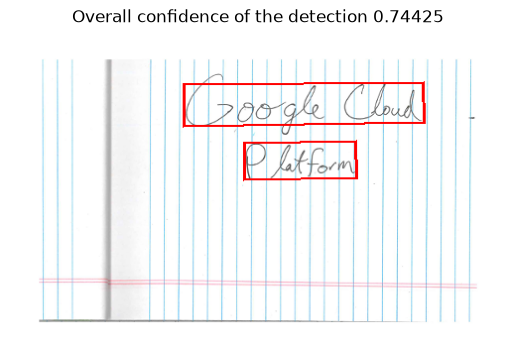

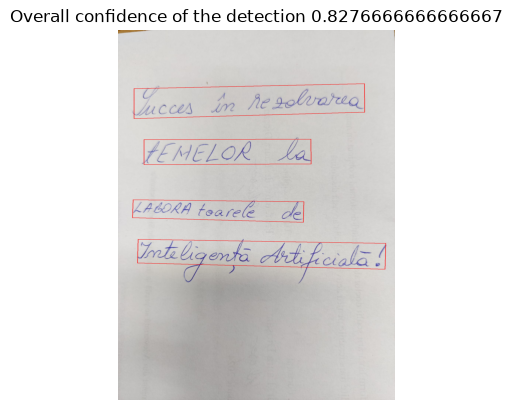

In [29]:
from PIL import ImageDraw
from matplotlib import pyplot as plt

test1 = []
test2 = []

for filePath in [ "test1.png", "test2.jpeg"]:
    img = Image.open(filePath)
    draw = ImageDraw.Draw(img)
    _, read_result = azureReqOCR(filePath)
    confidence_list = []
    for text_result in read_result.analyze_result.read_results:
        for line in text_result.lines:
            points = line.bounding_box
            polygon_points = [(points[i], points[i+1]) for i in range(0, len(points), 2)]
            confidence = sum([w.confidence for w in line.words]) / len(line.words)
            confidence_list.append(confidence)
            draw.polygon(polygon_points, outline="red", width=3)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Overall confidence of the detection " + str(sum(confidence_list)/len(confidence_list)))
    plt.show()

### Posibilitati de imbunatatire a recunoasterii textului

- Binarizare (Otsu Thresholding): Ajuta la separarea clara a scrisului de fundal.
- Deskewing: Corectarea inclinatiei textului inainte de OCR pentru a alinia caracterele.
- Modele Custom: Fine-tuning pe un dataset de scris de mana specific limbii romane (diacritice).


In [32]:
import easyocr
import cv2
import numpy as np

reader = easyocr.Reader(['ro', 'en'])

def evaluate_ocr(image_path):
    results = reader.readtext(image_path)

    full_text = " ".join([res[1] for res in results])
    avg_conf = np.mean([res[2] for res in results]) if results else 0

    return full_text, avg_conf

def preprocess_for_ocr(image_path):
    img = cv2.imread(image_path)
    # Conversie Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Denoising
    dst = cv2.fastNlMeansDenoising(gray, None, 10, 7, 21)
    # Thresholding adaptiv pentru contrast maxim
    thresh = cv2.adaptiveThreshold(dst, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

    processed_path = "processed_test2.png"
    cv2.imwrite(processed_path, thresh)
    return processed_path

original_text, original_conf = evaluate_ocr("test2.jpeg")
processed_path = preprocess_for_ocr("test2.jpeg")
new_text, new_conf = evaluate_ocr(processed_path)

print(f"Original Confidence: {original_conf:.4f}")
print(f"Processed Confidence: {new_conf:.4f}")
print(f"Text detectat: {new_text}")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/Users/rzv/remote/AI/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/rzv/remote/AI/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Original Confidence: 0.3744
Processed Confidence: 0.2827
Text detectat: Hcces U fle 2ola}reo #EMELo) LALoaA +oare( Jnntzligela o%Rcialz ! Da
